# 07 — User Profile Analysis

**Data:** `rating.csv` (20 M rows); **Part C** additionally uses `movie.csv` for genre tags.

| Part | Scope | Sections |
|------|-------|----------|
| **A — Population** | All 138 493 users | A1 Activity · A2 Popularity · A3 Rating dist · A4 Temporal · A5 Sparsity · A6 Archetypes |
| **B — Individual** | User 1 vs User 102680 | B1 Volume · B2 Rating dist · B3 Temporal · B4 Popularity · B5 Calibration |
| **C — User 666** | Median-activity anchor (RBM case study) | Genre × rating profile; hidden activations after a training setup is chosen |

**RBM:** Whether to use a **multi-user subset** (e.g. `04_netflix_rbm_training_cd1.ipynb`) or a **single-user** model (e.g. `06_user1_missing_rating_prediction.ipynb`) can be decided later. Part C establishes the **observable** profile for user 666 first; plug in trained \(W, b\) when you are ready to interpret \(p(h \mid V)\) from the Netflix paper equations.

---
## 0 · Setup & Data Loading

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# ── paths ──────────────────────────────────────────────────────────────────
root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent

rating_path = root / "data" / "rating.csv"
assert rating_path.exists(), f"Not found: {rating_path}"

# ── global style ───────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
COLORS = {"all": "#4C72B0", "u1": "#DD8452", "u102680": "#55A868"}
USER_IDS = [1, 102680]

# ── load ───────────────────────────────────────────────────────────────────
print("Loading rating.csv … (20 M rows, may take ~10 s)")
df = pd.read_csv(
    rating_path,
    dtype={"userId": "int32", "movieId": "int32", "rating": "float32"},
    parse_dates=["timestamp"],
)
print(f"  rows : {len(df):,}")
print(f"  users: {df['userId'].nunique():,}")
print(f"  movies: {df['movieId'].nunique():,}")
df.head(3)

Loading rating.csv … (20 M rows, may take ~10 s)
  rows : 20,000,263
  users: 138,493
  movies: 26,744


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39


---
# Part A — User View
---

## A1 · User Activity Distribution

How many movies has each user rated?  
The distribution reveals the long-tail structure of user engagement.

,value,userId
statistic,,
min,20.00000,36
median,68.00000,666
P50,68.00000,666
P75,155.00000,490
P90,334.00000,2241
P95,520.00000,3295
P99,1113.08000,27463
max,9254.00000,118205
mean,144.41353,1250



User 1      : 175 ratings
User 102680 : 1865 ratings


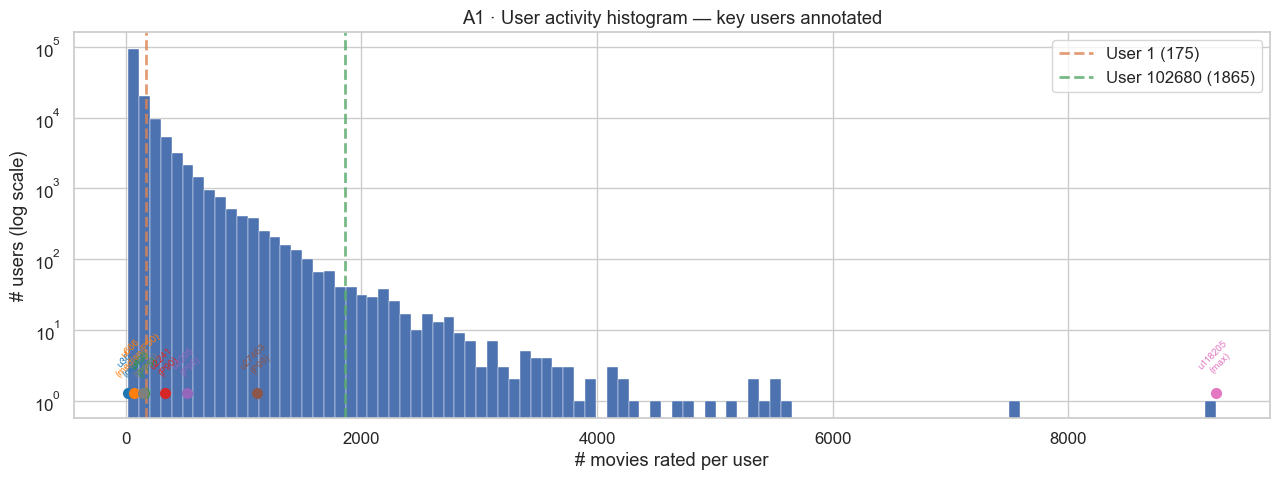

In [3]:
user_counts = df.groupby("userId")["movieId"].count().rename("n_rated")

def nearest_user(target_val):
    """Return the userId whose rating count is closest to target_val."""
    idx = (user_counts - target_val).abs().idxmin()
    return int(idx)

pcts = [50, 75, 90, 95, 99]
rows = []
for label, val in [
    ("min",    float(user_counts.min())),
    ("median", float(user_counts.median())),
    *[(f"P{p}", float(user_counts.quantile(p/100))) for p in pcts],
    ("max",    float(user_counts.max())),
    ("mean",   float(user_counts.mean())),
]:
    uid = nearest_user(val)
    rows.append({"statistic": label, "value": val, "userId": uid})

stats_df = pd.DataFrame(rows).set_index("statistic")
display(stats_df)
print(f"\nUser 1      : {user_counts.get(1, 'N/A')} ratings")
print(f"User 102680 : {user_counts.get(102680, 'N/A')} ratings")

fig, ax = plt.subplots(figsize=(13, 5))

ax.hist(user_counts, bins=100, color=COLORS["all"], edgecolor="white", linewidth=0.3)
ax.set_yscale("log")
ax.set_xlabel("# movies rated per user")
ax.set_ylabel("# users (log scale)")
ax.set_title("A1 · User activity histogram — key users annotated")

# ── stats table users — plot as dots on the x-axis ───────────────────────
# deduplicate by (userId, n_rated) so median==P50 only draws once
seen = set()
stat_markers = []
for row in rows:
    uid  = row["userId"]
    n    = int(user_counts[uid])
    stat = row["statistic"]
    key  = (uid, n)
    if key not in seen:
        stat_markers.append((uid, n, stat))
        seen.add(key)
    else:
        for i, (u, nv, s) in enumerate(stat_markers):
            if (u, nv) == key:
                stat_markers[i] = (u, nv, s + "/" + stat)
                break

cmap = plt.cm.tab10
dot_y = 1.3   # just above the x-axis (log scale starts near 1)

for i, (uid, n, stat) in enumerate(stat_markers):
    color = cmap(i % 10)
    ax.plot(n, dot_y, "o", color=color, markersize=7, zorder=5)
    ax.annotate(f"u{uid}\n({stat})",
                xy=(n, dot_y), xytext=(0, 10),
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=7, color=color,
                rotation=45)

# ── highlight the two focus users ─────────────────────────────────────────
for uid, col, lbl in [(1, COLORS["u1"], "User 1"),
                      (102680, COLORS["u102680"], "User 102680")]:
    n = user_counts.get(uid, 0)
    ax.axvline(n, color=col, lw=2, linestyle="--", label=f"{lbl} ({n})", alpha=0.8)

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## A2 · Top 10 most active users

In [4]:
# ── Find the top-10 most active users ────────────────────────────────────
TOTAL_MOVIES = df["movieId"].nunique()

top10_users = user_counts.nlargest(10).reset_index()
top10_users.columns = ["userId", "n_rated"]
# coverage_% = movies rated by this user / total movies in catalog × 100
# A typical user covers only ~0.25% of the catalog — the root cause of extreme matrix sparsity.
top10_users["coverage_%"] = (top10_users["n_rated"] / TOTAL_MOVIES * 100).round(2)
top10_users["mean_rating"] = top10_users["userId"].map(
    df.groupby("userId")["rating"].mean().round(3)
)
top10_users.index += 1  # rank from 1
top10_users.index.name = "rank"
print("Top 10 most active users:")
print(f"  (coverage_% = movies rated / {TOTAL_MOVIES:,} total movies in catalog × 100;"
      f"  median user covers only ~{(user_counts.median() / TOTAL_MOVIES * 100):.2f}% — extreme sparsity)")
display(top10_users)

# ── Highlight the #1 user ─────────────────────────────────────────────────
superuser_id   = int(user_counts.idxmax())
superuser_n    = int(user_counts.max())
superuser_cov  = superuser_n / TOTAL_MOVIES * 100
superuser_mean = df[df["userId"] == superuser_id]["rating"].mean()


# print(f"\n★  #1 most active user")
# print(f"   userId       : {superuser_id}")
# print(f"   Movies rated : {superuser_n:,}  ({superuser_cov:.1f}% of full catalog)")
# print(f"   Mean rating  : {superuser_mean:.3f}")
# print(f"\n   Compare:")
# print(f"   User 1      → {user_counts.get(1, 0):,} ratings ({user_counts.get(1, 0)/TOTAL_MOVIES*100:.2f}%)")
# print(f"   User 102680 → {user_counts.get(102680, 0):,} ratings ({user_counts.get(102680, 0)/TOTAL_MOVIES*100:.2f}%)")
# print(f"   User {superuser_id} (★) → {superuser_n:,} ratings ({superuser_cov:.2f}%)")

Top 10 most active users:
  (coverage_% = movies rated / 26,744 total movies in catalog × 100;  median user covers only ~0.25% — extreme sparsity)


,userId,n_rated,coverage_%,mean_rating
rank,,,,
1,118205,9254,34.60,3.279
2,8405,7515,28.10,3.208
3,82418,5646,21.11,3.517
4,121535,5520,20.64,2.793
5,125794,5491,20.53,3.763
6,74142,5447,20.37,1.577
7,34576,5356,20.03,3.012
8,131904,5330,19.93,3.249
9,83090,5169,19.33,2.405


## A3 · Global Rating Distribution

What does the 0.5 – 5.0 scale look like across all 20 M ratings?  
Are users generally generous? Do they prefer whole numbers?

Global mean  : 3.526
Global median: 3.5
Half-step ratings (x.5): 25.7% of all ratings
Whole-step ratings (x.0): 74.3% of all ratings


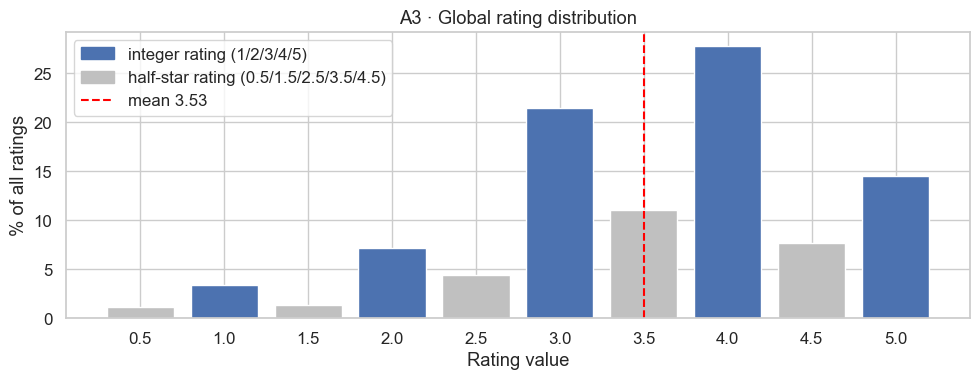

In [5]:
rating_vals = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
counts = df["rating"].value_counts().reindex(rating_vals, fill_value=0)
pcts_r = counts / counts.sum() * 100

global_mean = df["rating"].mean()
global_median = df["rating"].median()
print(f"Global mean  : {global_mean:.3f}")
print(f"Global median: {global_median:.1f}")
print(f"Half-step ratings (x.5): {pcts_r[[0.5,1.5,2.5,3.5,4.5]].sum():.1f}% of all ratings")
print(f"Whole-step ratings (x.0): {pcts_r[[1.0,2.0,3.0,4.0,5.0]].sum():.1f}% of all ratings")

from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ["#c0c0c0" if v % 1 != 0 else COLORS["all"] for v in rating_vals]
ax.bar([str(v) for v in rating_vals], pcts_r.values, color=bar_colors, edgecolor="white")
ax.legend(handles=[
    Patch(color=COLORS["all"], label="integer rating (1/2/3/4/5)"),
    Patch(color="#c0c0c0", label="half-star rating (0.5/1.5/2.5/3.5/4.5)"),
    plt.Line2D([0],[0], color="red", linestyle="--", label=f"mean {global_mean:.2f}"),
])
ax.axvline(str(round(global_mean * 2) / 2), color="red", lw=1.5, linestyle="--")
ax.set_xlabel("Rating value")
ax.set_ylabel("% of all ratings")
ax.set_title("A3 · Global rating distribution")
plt.tight_layout()
plt.show()

## A4 · Temporal Trend (1995 – 2015)

When were ratings submitted? Are there activity peaks?  
Did average ratings shift over time?

Peak year: 2000  —  1,953,659 ratings  (15,004 active users)


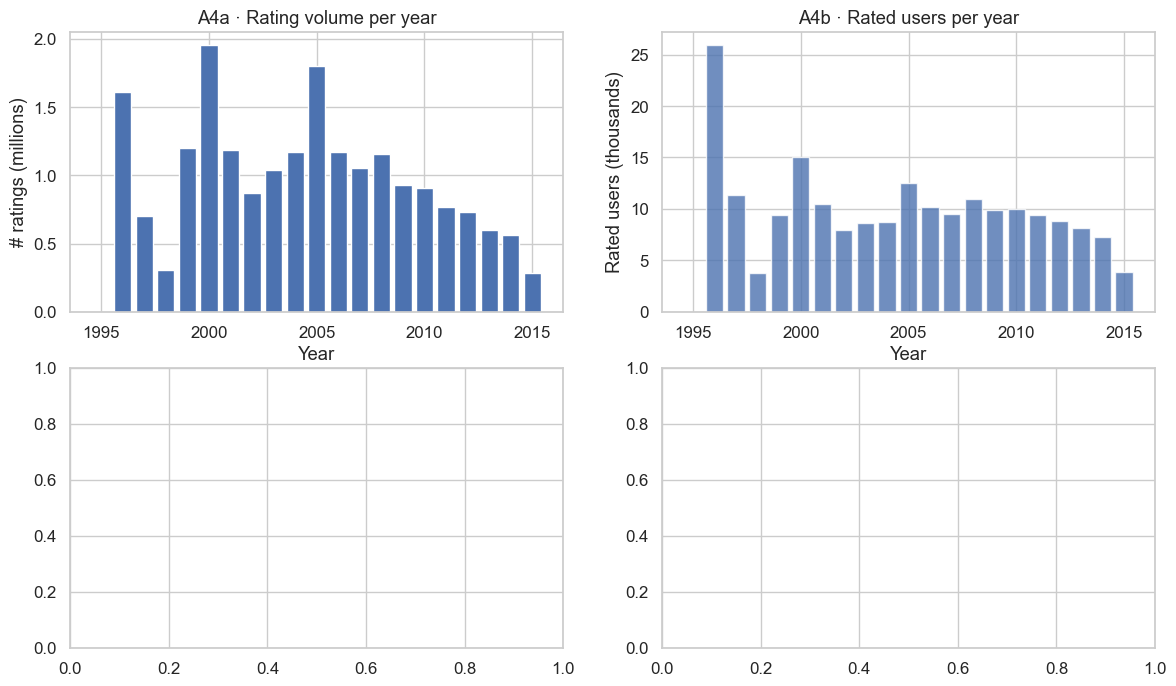

In [6]:
# ensure datetime
if not pd.api.types.is_datetime64_any_dtype(df["timestamp"]):
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s", errors="coerce")

df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.to_period("M")

yearly = df.groupby("year").agg(
    n_ratings=("rating", "count"),
    mean_rating=("rating", "mean"),
    n_users=("userId", "nunique"),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# A4a: ratings volume per year
ax = axes[0, 0]
ax.bar(yearly["year"], yearly["n_ratings"] / 1e6, color=COLORS["all"])
ax.set_xlabel("Year")
ax.set_ylabel("# ratings (millions)")
ax.set_title("A4a · Rating volume per year")

# A4b: rated users per year
ax = axes[0, 1]
ax.bar(yearly["year"], yearly["n_users"] / 1e3, color=COLORS["all"], alpha=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Rated users (thousands)")
ax.set_title("A4b · Rated users per year")



peak = yearly.loc[yearly["n_ratings"].idxmax()]
print(f"Peak year: {int(peak['year'])}  —  {peak['n_ratings']:,.0f} ratings  ({peak['n_users']:,.0f} active users)")

## A5 · Sparsity Overview

The user-item rating matrix has ~138 K rows × ~27 K columns.  
Only a tiny fraction of cells are filled — this sparsity is what makes RBM reconstruction non-trivial.

Users         :    138,493
Movies        :     26,744
Total cells   : 3,703,856,792
Observed ratings: 20,000,263
Fill rate     :      0.540%
Sparsity      :     99.460%

Per-user coverage (% of movies rated):
  median : 0.254%
  P99    : 4.16%
  User 1 : 0.654%
  User 102680: 6.974%


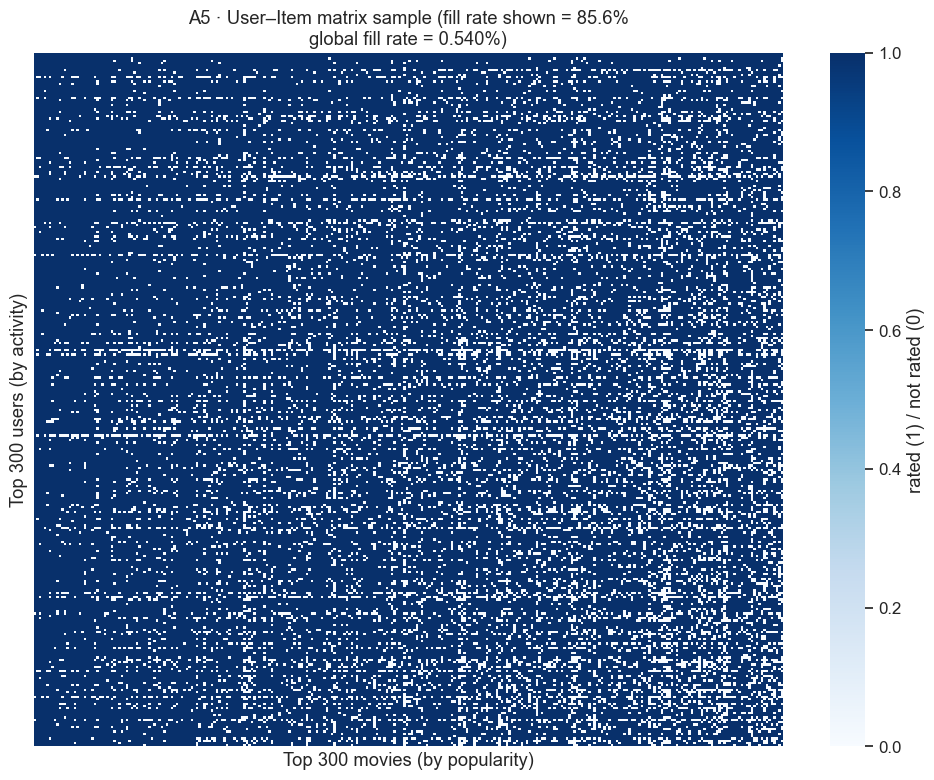

In [7]:
if "movie_counts" not in dir():
    movie_counts = df.groupby("movieId")["userId"].count().rename("n_raters")

n_users  = df["userId"].nunique()
n_movies = df["movieId"].nunique()
n_ratings = len(df)
total_cells = n_users * n_movies
fill_rate = n_ratings / total_cells * 100

print(f"Users         : {n_users:>10,}")
print(f"Movies        : {n_movies:>10,}")
print(f"Total cells   : {total_cells:>10,}")
print(f"Observed ratings: {n_ratings:>8,}")
print(f"Fill rate     : {fill_rate:>10.3f}%")
print(f"Sparsity      : {100-fill_rate:>10.3f}%")

# Per-user sparsity stats
user_fill = (user_counts / n_movies * 100)
print(f"\nPer-user coverage (% of movies rated):")
print(f"  median : {user_fill.median():.3f}%")
print(f"  P99    : {user_fill.quantile(0.99):.2f}%")
print(f"  User 1 : {user_fill.get(1, 0):.3f}%")
print(f"  User 102680: {user_fill.get(102680, 0):.3f}%")

# Visualise: sample of the matrix as a heatmap
SAMPLE_USERS  = 300
SAMPLE_MOVIES = 300

# pick top-N most active users and top-N most popular movies for visibility
top_users  = user_counts.nlargest(SAMPLE_USERS).index
top_movies = movie_counts.nlargest(SAMPLE_MOVIES).index

sub = df[df["userId"].isin(top_users) & df["movieId"].isin(top_movies)]
mat = sub.pivot_table(index="userId", columns="movieId", values="rating", fill_value=0)
# reindex to enforce dimensions
mat = mat.reindex(index=top_users, columns=top_movies, fill_value=0)
presence = (mat > 0).astype(int)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    presence,
    ax=ax,
    cmap="Blues",
    xticklabels=False,
    yticklabels=False,
    cbar_kws={"label": "rated (1) / not rated (0)"},
)
ax.set_xlabel(f"Top {SAMPLE_MOVIES} movies (by popularity)")
ax.set_ylabel(f"Top {SAMPLE_USERS} users (by activity)")
fill_sub = presence.values.mean() * 100
ax.set_title(
    f"A5 · User–Item matrix sample (fill rate shown = {fill_sub:.1f}%\n"
    f"global fill rate = {fill_rate:.3f}%)"
)
plt.tight_layout()
plt.show()

## A6 · User Rating Archetypes

Using **mean** (optimism) and **std dev** (spread) simultaneously, we identify four archetypal rating styles and surface a representative userId for each.

| Archetype | Signature |
|---|---|
| **Optimist** | high mean, low std — almost always rates 4 or 5 |
| **Critic** | low mean, low std — consistently harsh |
| **Polarized** | high std — loves or hates, rarely in between |
| **Consistent moderate** | mean near global average, lowest std — very predictable |


Representative userId per archetype:


/var/folders/8l/bqykkvkj5vz4ffw8hmxk7p1w0000gn/T/ipykernel_5929/3062944009.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  user_profile["entropy"] = df.groupby("userId").apply(_entropy)


,userId,n_rated,mean,std,entropy (bits)
archetype,,,,,
Optimist,138325,1700,4.361,0.645,2.035
Critic,83090,5169,2.405,0.688,1.408
Polarized,30874,58,2.914,2.256,1.103
Consistent,26480,1174,3.508,0.365,1.535



  [Optimist]  userId 138325  —  Rates almost everything highly (avg 4.36/5). Spread is narrow (std 0.65) — genuinely likes most movies.
  [Critic]  userId 83090  —  Consistently low scores (avg 2.4/5, std 0.69). Hard to please — rarely gives more than 3 stars.
  [Polarized]  userId 30874  —  Extreme ratings only (std 2.26, the highest in the dataset). Either loves it or hates it — almost never rates in the middle.
  [Consistent]  userId 26480  —  Avg 3.51/5, std just 0.37 — ratings cluster tightly around the global mean. Almost every score falls within a narrow band, across all 1,174 movies rated.


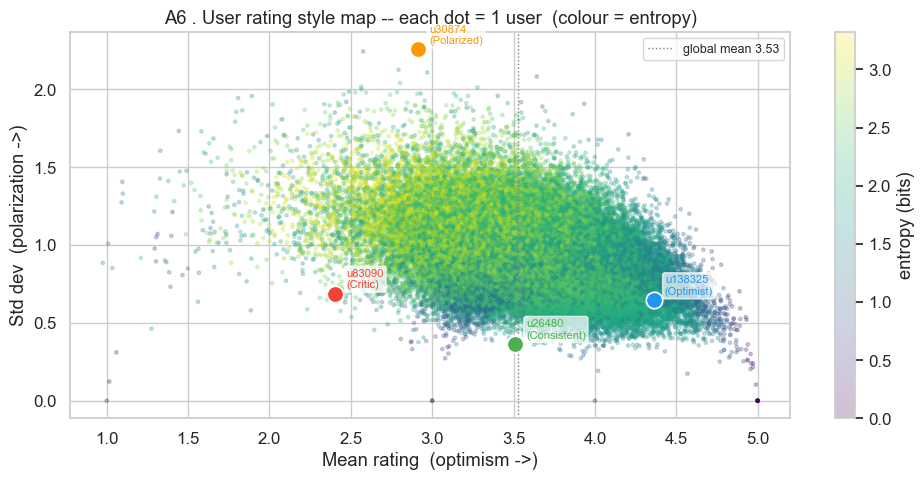

In [8]:
from scipy.stats import entropy as sp_entropy

# ── Per-user stats (min 50 ratings for reliable estimates) ───────────────
MIN_N = 50

def _entropy(group):
    counts = group["rating"].value_counts()
    probs  = counts / counts.sum()
    return float(sp_entropy(probs.values, base=2))

user_profile = (
    df.groupby("userId")["rating"]
    .agg(mean="mean", std="std", n="count")
    .query("n >= @MIN_N")
    .copy()
)
user_profile["entropy"] = df.groupby("userId").apply(_entropy)
user_profile = user_profile.dropna()

# ── Identify archetypes ───────────────────────────────────────────────────
p95_mean = user_profile["mean"].quantile(0.95)
p05_mean = user_profile["mean"].quantile(0.05)
p25_std  = user_profile["std"].quantile(0.25)
gm       = df["rating"].mean()

opt_pool  = user_profile[(user_profile["mean"] >= p95_mean) & (user_profile["std"] <= p25_std)]
crit_pool = user_profile[(user_profile["mean"] <= p05_mean) & (user_profile["std"] <= p25_std)]
mod_pool  = user_profile[user_profile["mean"].between(gm - 0.1, gm + 0.1)]

optimist_id   = int(opt_pool.nlargest(1, "n").index[0])  if len(opt_pool)  else int(user_profile["mean"].idxmax())
critic_id     = int(crit_pool.nlargest(1, "n").index[0]) if len(crit_pool) else int(user_profile["mean"].idxmin())
polarized_id  = int(user_profile["std"].idxmax())
consistent_id = int(mod_pool["std"].idxmin()) if len(mod_pool) else int(user_profile["std"].idxmin())

archetypes = {
    "Optimist":   optimist_id,
    "Critic":     critic_id,
    "Polarized":  polarized_id,
    "Consistent": consistent_id,
}

# ── Summary table with plain-language description ─────────────────────────
def describe(label, uid):
    r = user_profile.loc[uid]
    m, s, e, n = round(r["mean"], 2), round(r["std"], 2), round(r["entropy"], 2), int(r["n"])
    if label == "Optimist":
        return (f"Rates almost everything highly (avg {m}/5). "
                f"Spread is narrow (std {s}) — genuinely likes most movies.")
    elif label == "Critic":
        return (f"Consistently low scores (avg {m}/5, std {s}). "
                f"Hard to please — rarely gives more than 3 stars.")
    elif label == "Polarized":
        return (f"Extreme ratings only (std {s}, the highest in the dataset). "
                f"Either loves it or hates it — almost never rates in the middle.")
    else:
        return (f"Avg {m}/5, std just {s} — ratings cluster tightly around the global mean. "
                f"Almost every score falls within a narrow band, across all {n:,} movies rated.")

rows = []
for label, uid in archetypes.items():
    r = user_profile.loc[uid]
    rows.append({"archetype": label, "userId": uid,
                 "n_rated": int(r["n"]), "mean": round(r["mean"], 3),
                 "std": round(r["std"], 3), "entropy (bits)": round(r["entropy"], 3)})
print("Representative userId per archetype:")
display(pd.DataFrame(rows).set_index("archetype"))

print()
for label, uid in archetypes.items():
    print(f"  [{label}]  userId {uid}  —  {describe(label, uid)}")

# ── Scatter: mean vs std, colour = entropy ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(
    user_profile["mean"], user_profile["std"],
    c=user_profile["entropy"], cmap="viridis",
    alpha=0.25, s=6, rasterized=True
)
plt.colorbar(sc, ax=ax, label="entropy (bits)")

arch_colors = ["#2196F3", "#F44336", "#FF9800", "#4CAF50"]
for (label, uid), col in zip(archetypes.items(), arch_colors):
    r = user_profile.loc[uid]
    ax.scatter(r["mean"], r["std"], color=col, s=140, zorder=6,
               edgecolors="white", linewidths=1.2)
    ax.annotate(f"u{uid}\n({label})",
                xy=(r["mean"], r["std"]),
                xytext=(8, 4), textcoords="offset points",
                fontsize=8, color=col,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

ax.axvline(gm, color="grey", lw=1, linestyle=":", label=f"global mean {gm:.2f}")
ax.set_xlabel("Mean rating  (optimism ->)")
ax.set_ylabel("Std dev  (polarization ->)")
ax.set_title("A6 . User rating style map -- each dot = 1 user  (colour = entropy)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
# Part B — Movie View
---

## B1 · Movie Popularity — Long Tail

How many users have rated each movie?  
Classic power-law: a few blockbusters dominate, most movies are rarely seen.

Movies rated by at least N users:
  ≥    1 raters: 26,744 movies  (100.0%)
  ≥    5 raters: 18,345 movies  (68.6%)
  ≥   10 raters: 15,451 movies  (57.8%)
  ≥   50 raters: 10,524 movies  (39.4%)
  ≥  100 raters:  8,546 movies  (32.0%)
  ≥  500 raters:  4,489 movies  (16.8%)


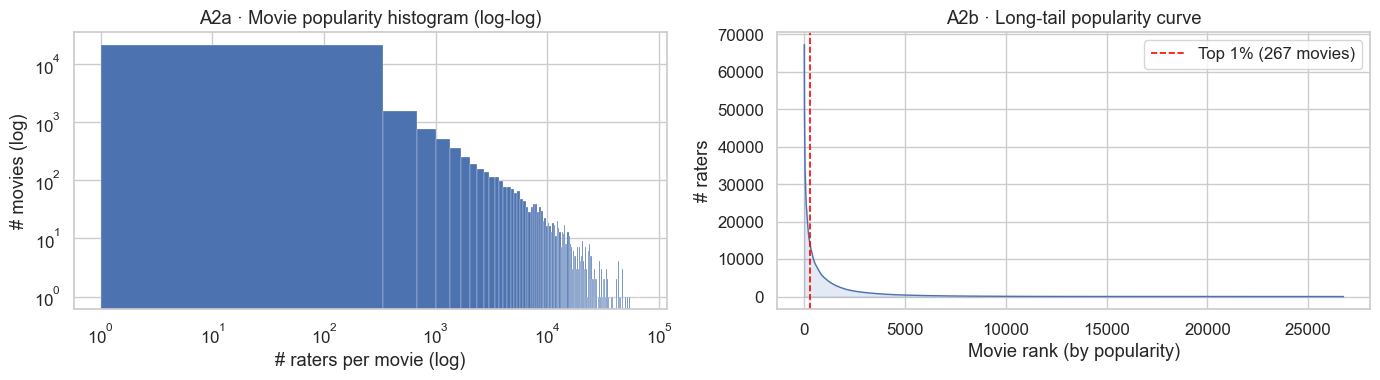


Top 10 most-rated movies (movieId | # raters):
movieId
296     67310
356     66172
318     63366
593     63299
480     59715
260     54502
110     53769
589     52244
2571    51334
527     50054


In [9]:
movie_counts = df.groupby("movieId")["userId"].count().rename("n_raters")
total_movies_in_db = df["movieId"].nunique()

thresholds = [1, 5, 10, 50, 100, 500]
print("Movies rated by at least N users:")
for t in thresholds:
    n = (movie_counts >= t).sum()
    print(f"  ≥ {t:>4} raters: {n:>6,} movies  ({n/total_movies_in_db*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: histogram of rater counts (log-log)
ax = axes[0]
ax.hist(movie_counts, bins=200, color=COLORS["all"], edgecolor="white", linewidth=0.2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("# raters per movie (log)")
ax.set_ylabel("# movies (log)")
ax.set_title("A2a · Movie popularity histogram (log-log)")

# right: sorted popularity curve (long tail)
ax2 = axes[1]
sorted_pop = np.sort(movie_counts.values)[::-1]
ax2.plot(range(1, len(sorted_pop)+1), sorted_pop, color=COLORS["all"], lw=1)
ax2.fill_between(range(1, len(sorted_pop)+1), sorted_pop, alpha=0.15, color=COLORS["all"])
ax2.set_xlabel("Movie rank (by popularity)")
ax2.set_ylabel("# raters")
ax2.set_title("A2b · Long-tail popularity curve")
# annotate top-1% cutoff
cutoff = int(len(sorted_pop) * 0.01)
ax2.axvline(cutoff, color="red", lw=1.2, linestyle="--", label=f"Top 1% ({cutoff} movies)")
ax2.legend()

plt.tight_layout()
plt.show()

# Top-10 most rated movies
print("\nTop 10 most-rated movies (movieId | # raters):")
print(movie_counts.sort_values(ascending=False).head(10).to_string())

---
# Part C — User 666 (median-activity anchor)

**Prerequisites:** Run **§0 through A2** so `df`, `user_counts`, `TOTAL_MOVIES`, and `COLORS` exist. Part B can be skipped.

**Who:** In **A1**, the user closest to the population **median** activity (~68 ratings) is **userId 666**.

**Structure (echoes Part A):**

| Block | Mirrors | What you see for user 666 |
|-------|---------|---------------------------|
| **C1** | **A1** Activity | Where 666 sits on the global histogram of `#` ratings per user |
| **C2** | **A2** Popularity | Distribution of **movie popularity** (# raters) among films 666 rated |
| **C3** | **A3** Rating mix | Bar comparison: **global** % vs **666** % at each half-star level |
| **C4** | **A4** Temporal | Cumulative ratings over time |
| **C5** | **A5** Sparsity | **100% stacked bar**: rated share vs unseen share of the full catalog (same number as “coverage”) |
| **C6** | *(genre)* | Top genre tags (multi-label per film) |

Below the plots, the notebook walks through the **Netflix RBM** construction—**visible units → weight tensor → hidden conditional**—with a **bipartite schematic** and **Step 1:** the real **\(V\)** block for user 666 (no weights / no hidden yet). Trained \(W,b\) from either a multi-user subset or a single-user model plug in when you interpret \(p(h \mid V)\).

,User 666
Metric,
# ratings,68
Coverage of catalog,0.25%
Activity percentile (users with fewer ratings),49.9th
Mean rating,3.897
Std dev,0.995
Half-star usage (% of ratings),0.0%
Median popularity of rated movies (# raters),15296
Mean Δ vs global mean (per rating),0.372
% ratings above global mean,69.1%


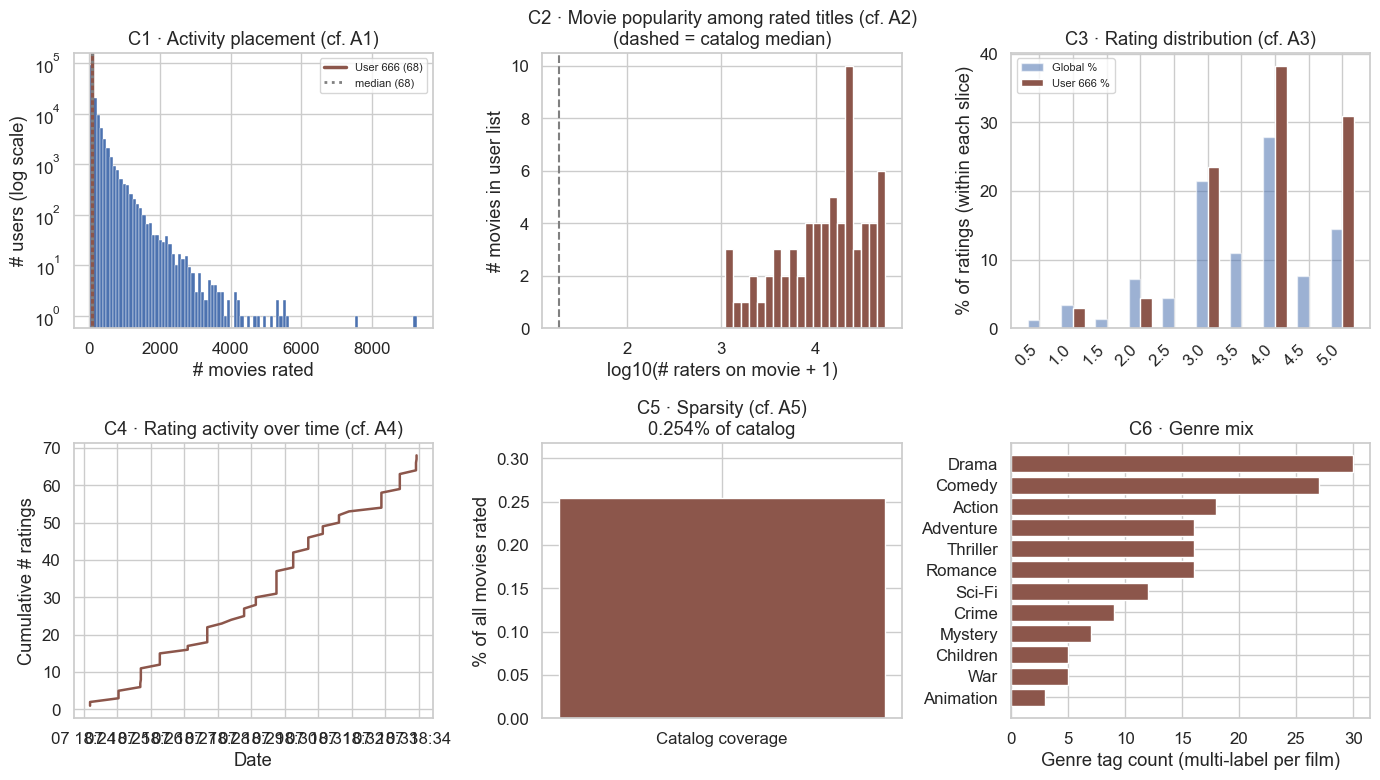

Global mean (all rows): 3.5255  |  User 666 mean: 3.8971


In [10]:
# Part C — User 666: C1–C6 mirror Part A (needs §0–A2: df, user_counts, TOTAL_MOVIES, COLORS, root)
from collections import Counter

UID_FOCUS = 666
COLOR_666 = "#8C564B"

movie_path = root / "data" / "movie.csv"
assert movie_path.exists(), f"Not found: {movie_path}"

movies_meta = pd.read_csv(movie_path, dtype={"movieId": "int32"})

def _split_genres(s):
    if pd.isna(s) or s == "(no genres listed)":
        return []
    return [x.strip() for x in str(s).split("|")]

movie_genres = dict(
    zip(movies_meta["movieId"].astype(int), movies_meta["genres"].map(_split_genres))
)

u666 = df[df["userId"] == UID_FOCUS].copy()
if u666.empty:
    raise ValueError(f"No rows for userId {UID_FOCUS} — check rating.csv.")

n_rated = len(u666)
if UID_FOCUS in user_counts.index:
    assert n_rated == int(user_counts.loc[UID_FOCUS]), "user_counts vs df mismatch"

global_mean = float(df["rating"].mean())
activity_pct = (user_counts < n_rated).mean() * 100

movie_popularity = df.groupby("movieId")["userId"].count()
u666["popularity"] = u666["movieId"].map(movie_popularity)

genre_counts = Counter()
for mid in u666["movieId"]:
    for g in movie_genres.get(int(mid), []):
        genre_counts[g] += 1

rating_vals = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
g_counts = df["rating"].value_counts().reindex(rating_vals, fill_value=0)
g_pct = g_counts / g_counts.sum() * 100
u_counts = u666["rating"].value_counts().reindex(rating_vals, fill_value=0)
u_pct = u_counts / max(u_counts.sum(), 1) * 100

# ── summary (numbers behind the plots) ───────────────────────────────────────
summary_666 = pd.DataFrame(
    {
        "Metric": [
            "# ratings",
            "Coverage of catalog",
            "Activity percentile (users with fewer ratings)",
            "Mean rating",
            "Std dev",
            "Half-star usage (% of ratings)",
            "Median popularity of rated movies (# raters)",
            "Mean Δ vs global mean (per rating)",
            "% ratings above global mean",
        ],
        "User 666": [
            n_rated,
            f"{n_rated / TOTAL_MOVIES * 100:.2f}%",
            f"{activity_pct:.1f}th",
            f"{u666['rating'].mean():.3f}",
            f"{u666['rating'].std():.3f}",
            f"{(u666['rating'] % 1 != 0).mean() * 100:.1f}%",
            f"{u666['popularity'].median():.0f}",
            f"{(u666['rating'] - global_mean).mean():.3f}",
            f"{(u666['rating'] > global_mean).mean() * 100:.1f}%",
        ],
    }
)
display(summary_666.set_index("Metric"))

# ── C1–C6 figures (same order as Part A) ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# C1 — Activity (cf. A1)
ax = axes[0, 0]
ax.hist(user_counts, bins=100, color=COLORS["all"], edgecolor="white", linewidth=0.3)
ax.set_yscale("log")
ax.axvline(n_rated, color=COLOR_666, lw=2.5, label=f"User {UID_FOCUS} ({n_rated})")
ax.axvline(user_counts.median(), color="gray", ls=":", lw=2, label=f"median ({user_counts.median():.0f})")
ax.set_xlabel("# movies rated")
ax.set_ylabel("# users (log scale)")
ax.set_title("C1 · Activity placement (cf. A1)")
ax.legend(fontsize=8)

# C2 — Popularity of titles rated (cf. A2)
ax = axes[0, 1]
pop_u = u666["popularity"].astype(float)
ax.hist(np.log10(pop_u + 1), bins=min(20, max(5, n_rated // 3)), color=COLOR_666, edgecolor="white")
ax.axvline(np.log10(movie_popularity.median() + 1), color="gray", ls="--", lw=1.5)
ax.set_xlabel("log10(# raters on movie + 1)")
ax.set_ylabel("# movies in user list")
ax.set_title("C2 · Movie popularity among rated titles (cf. A2)\n(dashed = catalog median)")

# C3 — Rating mix vs global (cf. A3)
ax = axes[0, 2]
x = np.arange(len(rating_vals))
w = 0.35
ax.bar(x - w / 2, g_pct.values, width=w, label="Global %", color=COLORS["all"], alpha=0.55, edgecolor="white")
ax.bar(x + w / 2, u_pct.values, width=w, label=f"User {UID_FOCUS} %", color=COLOR_666, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in rating_vals], rotation=45, ha="right")
ax.set_ylabel("% of ratings (within each slice)")
ax.set_title("C3 · Rating distribution (cf. A3)")
ax.legend(fontsize=8)

# C4 — Temporal (cf. A4)
ax = axes[1, 0]
ts = u666.sort_values("timestamp")
ax.plot(ts["timestamp"], np.arange(1, len(ts) + 1), color=COLOR_666, lw=1.8)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative # ratings")
ax.set_title("C4 · Rating activity over time (cf. A4)")

# C5 — Sparsity / coverage (cf. A5)
ax = axes[1, 1]
cov = n_rated / TOTAL_MOVIES * 100
ax.bar(["Catalog coverage"], [cov], color=COLOR_666, edgecolor="white")
ax.set_ylabel("% of all movies rated")
ax.set_title(f"C5 · Sparsity (cf. A5)\n{cov:.3f}% of catalog")
ax.set_ylim(0, max(cov * 1.25, 0.05))

# C6 — Genre (multi-label)
ax = axes[1, 2]
top_g = genre_counts.most_common(12)
if top_g:
    labs = [g for g, _ in top_g]
    vals = [c for _, c in top_g]
    ax.barh(labs[::-1], vals[::-1], color=COLOR_666, edgecolor="white")
    ax.set_xlabel("Genre tag count (multi-label per film)")
    ax.set_title("C6 · Genre mix")

plt.tight_layout()
plt.show()

print(
    f"Global mean (all rows): {global_mean:.4f}  |  User {UID_FOCUS} mean: {u666['rating'].mean():.4f}"
)


### Netflix-style RBM on user 666 — visible → weights → hidden

This follows the same notation as `01_netflix_visible_units.ipynb`, `02_netflix_weights_and_hidden_units.ipynb`, and `04_netflix_rbm_training_cd1.ipynb`.

---

**Step 1 (next code cell):** build **V** for user 666 only — **N = number of ratings**, **K = 10** half-star bins. Output: full table + heatmap; **no weights / no hidden**. Unrated movies are **not** columns here (they are prediction targets later).

**1. Visible layer (V).**  
For each movie `i` in the model, MovieLens uses `K=10` half-star levels `{0.5, ..., 5.0}`.

$$
V \in \{0,1\}^{K \times m}
$$

An observed rating is one-hot over the `K` units for that movie.

**2. Weight tensor (W).**  
Each link connects `(movie i, rating level k)` to hidden unit `j`:

$$
W_{ijk}, \quad \text{shape conceptually } K \times m \times F
$$

Weights are shared across users; users differ in which `v_i^k` are turned on.

**3. Hidden conditional (Eq. (2) in the Netflix RBM paper).**

$$
a_j = b_j + \sum_{i=1}^{m}\sum_{k=1}^{K} v_i^k W_{ijk}
$$

$$
p(h_j=1\mid V)=\sigma(a_j), \quad \sigma(x)=\frac{1}{1+e^{-x}}
$$

Equivalent single-line form of **Eq. (2)**:

$$
p(h_j = 1 \mid V) = \sigma\!\left(b_j + \sum_{i=1}^{m}\sum_{k=1}^{K} v_i^k W_{ijk}\right)
$$

**4. What “acts on user 666”?**  
Only movies user 666 actually rated contribute non-zero terms in the double sum; the chosen half-star level picks the one-hot `v_i^k`.

**5. Next step (Eq. (1) in the Netflix RBM paper).**  
Visible softmax reconstruction uses the same `W`:

$$
p(v_i^k=1\mid h)=\frac{\exp\left(b_i^k+\sum_j h_j W_{ijk}\right)}{\sum_{\ell=1}^{K}\exp\left(b_i^{\ell}+\sum_j h_j W_{ij\ell}\right)}
$$

CD-1 then updates parameters from data minus model statistics (see `04_netflix_rbm_training_cd1.ipynb`).

User 666: N = 68 rated movies → visible shape V is (K, N) = (10, 68). Total ones in V = 68 (must equal N). Unrated catalog movies are prediction targets, not columns here.


,col,movieId,timestamp,rating,level_index_k,half_star_level
0,0,1,1997-10-07 18:27:41,5.0,9,5.0
1,1,6,1997-10-07 18:30:15,4.0,7,4.0
2,2,17,1997-10-07 18:25:41,5.0,9,5.0
3,3,25,1997-10-07 18:30:15,5.0,9,5.0
4,4,32,1997-10-07 18:31:08,4.0,7,4.0
...,...,...,...,...,...,...
63,63,1488,1997-10-07 18:27:41,1.0,1,1.0
64,64,1569,1997-10-07 18:29:08,4.0,7,4.0
65,65,1580,1997-10-07 18:25:02,4.0,7,4.0
66,66,1584,1997-10-07 18:24:11,4.0,7,4.0


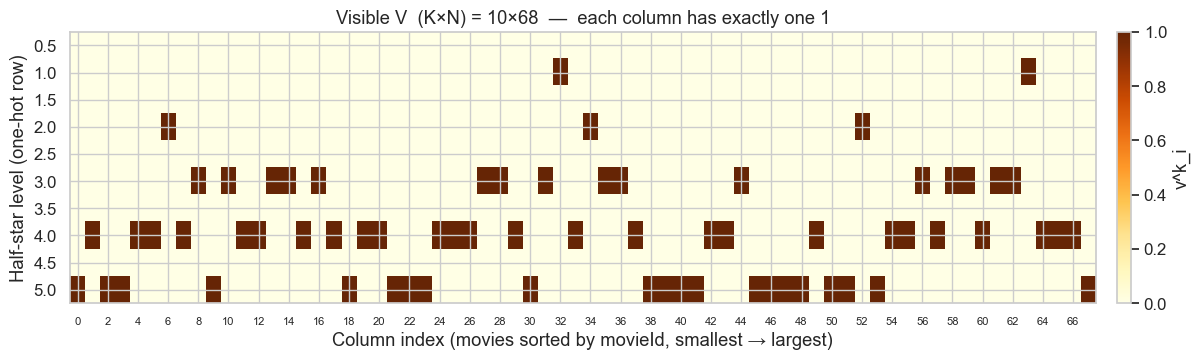

In [11]:
# Step 1 — Netflix-style visible block V for user 666 only (K=10 half-star levels)
# All rated movies → N columns; each column is one-hot over K rows. Unrated movies are not columns here.
import numpy as np

RATING_LEVELS = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
K = len(RATING_LEVELS)
rating_to_idx = {float(r): i for i, r in enumerate(RATING_LEVELS)}

vis = u666.sort_values("movieId").reset_index(drop=True)
N = len(vis)
V = np.zeros((K, N), dtype=np.float64)
level_idx = []
for col, row in vis.iterrows():
    ri = float(row["rating"])
    if ri not in rating_to_idx:
        raise ValueError(f"Rating {ri} not in K=10 half-star vocabulary")
    ki = rating_to_idx[ri]
    V[ki, col] = 1.0
    level_idx.append(ki)

visible_table = pd.DataFrame(
    {
        "col": np.arange(N, dtype=int),
        "movieId": vis["movieId"].values,
        "timestamp": vis["timestamp"].values,
        "rating": vis["rating"].values,
        "level_index_k": level_idx,
        "half_star_level": [RATING_LEVELS[k] for k in level_idx],
    }
)

print(
    f"User {UID_FOCUS}: N = {N} rated movies → visible shape V is (K, N) = ({K}, {N}). "
    f"Total ones in V = {int(V.sum())} (must equal N). Unrated catalog movies are prediction targets, not columns here."
)
assert float(V.sum()) == N
assert np.all(V.sum(axis=0) == 1.0)

display(visible_table)

# Heatmap: rows = 10 rating levels, cols = each rated movie (movieId ascending)
fig, ax = plt.subplots(figsize=(min(24, max(10, N * 0.18)), 3.8))
im = ax.imshow(V, aspect="auto", cmap="YlOrBr", interpolation="nearest", vmin=0, vmax=1)
ax.set_yticks(range(K))
ax.set_yticklabels([str(x) for x in RATING_LEVELS])
step = max(1, N // 25)
ax.set_xticks(range(0, N, step))
ax.set_xticklabels([str(i) for i in range(0, N, step)], fontsize=8)
ax.set_xlabel("Column index (movies sorted by movieId, smallest → largest)")
ax.set_ylabel("Half-star level (one-hot row)")
ax.set_title(f"Visible V  (K×N) = {K}×{N}  —  each column has exactly one 1")
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label="v^k_i")
plt.tight_layout()
plt.show()


RBM visible & hidden neurons graph example

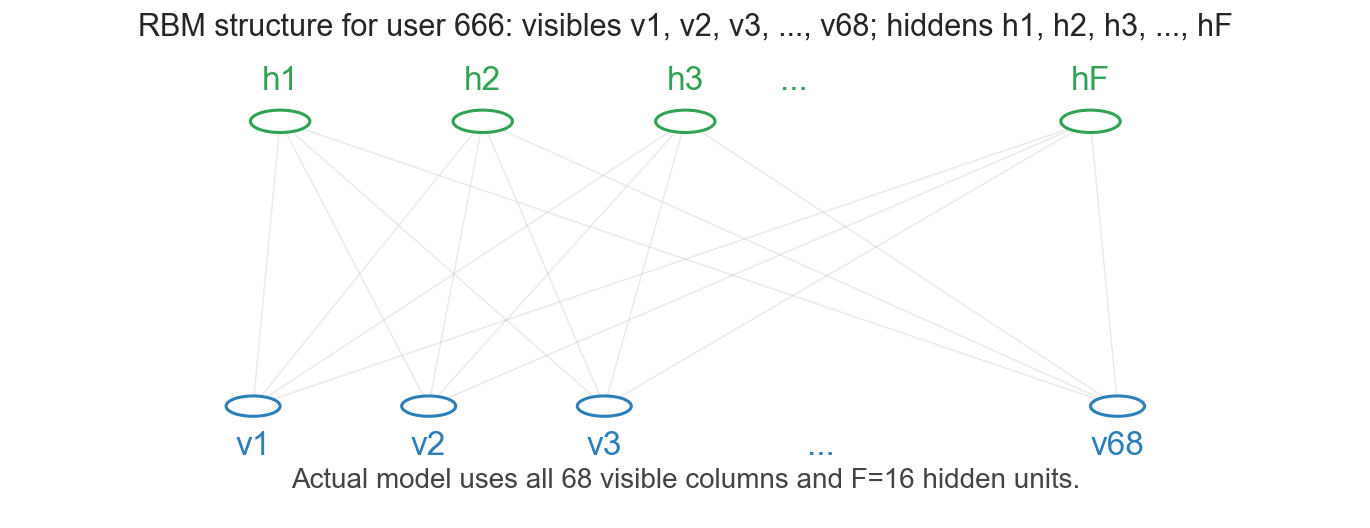

In [12]:
import matplotlib.pyplot as plt

# Conceptual view (readable): show indexed endpoints with ellipsis, not all 68 circles.
N_vis = 68   # fixed by user 666 observed ratings
F_plot = 16  # current hidden size shown in this figure

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

y_vis, y_hid = 0.22, 0.78

# Pull endpoints toward center to remove excessive blank space
xv = [0.18, 0.31, 0.44, 0.82]   # v1, v2, v3, v68
xh = [0.20, 0.35, 0.50, 0.80]   # h1, h2, h3, hF

# Bigger circles and text for readability
r_vis, r_hid = 0.020, 0.022

# Light conceptual connections among shown nodes
for x1 in xv:
    for x2 in xh:
        ax.plot([x1, x2], [y_vis, y_hid], color="#b8b8b8", alpha=0.30, lw=1.1, zorder=1)

v_labels = ["v1", "v2", "v3", f"v{N_vis}"]
h_labels = ["h1", "h2", "h3", "hF"]

# Draw visible shown nodes + labels
for x, lab in zip(xv, v_labels):
    ax.add_patch(plt.Circle((x, y_vis), r_vis, facecolor="white", edgecolor="#2c7fb8", lw=2.2, zorder=3))
    ax.text(x, y_vis - 0.048, lab, ha="center", va="top", fontsize=24, color="#2c7fb8")

# Draw hidden shown nodes + labels
for x, lab in zip(xh, h_labels):
    ax.add_patch(plt.Circle((x, y_hid), r_hid, facecolor="white", edgecolor="#31a354", lw=2.2, zorder=3))
    ax.text(x, y_hid + 0.048, lab, ha="center", va="bottom", fontsize=24, color="#31a354")

# Ellipsis markers closer to node groups
ax.text(0.60, y_vis - 0.048, "...", ha="center", va="top", fontsize=24, color="#2c7fb8")
ax.text(0.58, y_hid + 0.048, "...", ha="center", va="bottom", fontsize=24, color="#31a354")

ax.text(
    0.5,
    0.95,
    f"RBM structure for user 666: visibles v1, v2, v3, ..., v{N_vis}; hiddens h1, h2, h3, ..., hF",
    ha="center",
    fontsize=22,
)
ax.text(
    0.5,
    0.06,
    f"Actual model uses all {N_vis} visible columns and F={F_plot} hidden units.",
    ha="center",
    fontsize=20,
    color="#444444",
)

plt.tight_layout()
plt.show()



### Step 2 — One Complete Training Iteration Contrastive Divergence (CD)-1 for User 666

#### Input: One User 666's  rating vector v⁰, total 68

#### 1. Initialize weights and biases
- loop: **$V \rightarrow h \rightarrow V$**
- Start from observed visible block $V$ for user 666 (here $K=10$, $N=68$).
- Set hidden size $F$ as a trial hyperparameter (**here we set $F=16$**).

Weight scale
- Initialize weights $W$ randomly with small values; initialize biases ($b_v, b_h$) at zero.

- Weight tensor shape is $(K, N, F) = (10, 68, 16)$. with random values from N(0, 0.01)
- Total number of weight parameters is:

$$
10 \times 68 \times 16 = 10880
$$

Also prints weight summary and plots the **initial weight distribution**.

#### 2. Forward pass: 

From Eq. (2), $V \rightarrow h$:

$$
p(h_j=1\mid V)=\sigma\left(b_j+\sum_{i=1}^{N}\sum_{k=1}^{K} v_i^k W_{ijk}\right)
$$

Expected output is a hidden probability vector of length **$F=16$**.

#### 3. Backward pass (reconstruction): 
From Eq. (1), $h \rightarrow V$:

$$
p(v_i^k=1\mid h)=\frac{\exp\left(b_i^k+\sum_j h_j W_{ijk}\right)}{\sum_{\ell=1}^{K}\exp\left(b_i^{\ell}+\sum_j h_j W_{ij\ell}\right)}
$$

For user 666, this reconstruction is produced for **all $N=68$ visible columns** (each column has a 10-level distribution).





Initialized RBM parameters (Step 2):
  V shape      = (10, 68) (K, N)
  W shape      = (10, 68, 16) (K, N, F)
  b_v shape    = (10, 68) (K, N)
  b_h shape    = (16,) (F,)
  F            = 16 (trial hyperparameter)
  #weights     = 10 x 68 x 16 = 10880
  W stats      : min=-0.043891, max=0.040258, mean=-0.000120, std=0.010054
  W_init[0, :5, 0]  = [ 0.003047  0.003688 -0.005122  0.006789  0.007112]
  ||W||_F      = 1.048762


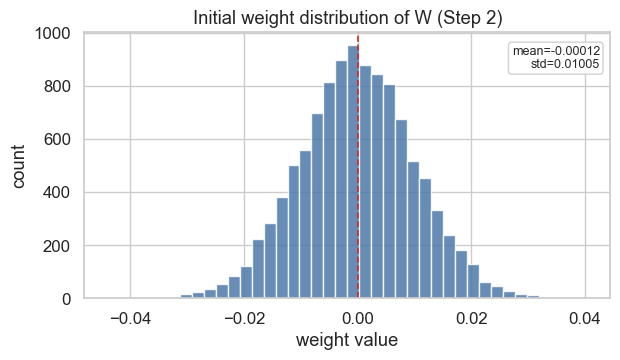

In [13]:
# Step 2 — Initialize paper-defined RBM parameters for user 666 pipeline
# This step sets trial F, initializes W randomly, and shows initial W distribution.

import numpy as np
import matplotlib.pyplot as plt

# Visible dimensions from Step 1
assert 'V' in globals(), 'Please run Step 1 first to build V.'
K, N = V.shape

# F = number of hidden units (trial hyperparameter for this run)
F = 16

# Small-random W breaks symmetry; biases start at zere, initialize mean-field weights
rng = np.random.default_rng(42)
W_init = rng.normal(loc=0.0, scale=0.01, size=(K, N, F)).astype(np.float64)  # W_{ijk}
b_v_init = np.zeros((K, N), dtype=np.float64)  # visible bias b_i^k
b_h_init = np.zeros(F, dtype=np.float64)       # hidden bias b_j (aka c_j in some papers)

print('Initialized RBM parameters (Step 2):')
print(f'  V shape      = {V.shape} (K, N)')
print(f'  W shape      = {W_init.shape} (K, N, F)')
print(f'  b_v shape    = {b_v_init.shape} (K, N)')
print(f'  b_h shape    = {b_h_init.shape} (F,)')
print(f'  F            = {F} (trial hyperparameter)')
print(f'  #weights     = {K} x {N} x {F} = {K*N*F}')
print(f'  W stats      : min={W_init.min():.6f}, max={W_init.max():.6f}, mean={W_init.mean():.6f}, std={W_init.std():.6f}')
print('  W_init[0, :5, 0]  =', np.round(W_init[0, :5, 0], 6))
print(f'  ||W||_F      = {np.linalg.norm(W_init):.6f}')

# Initial weight distribution plot
w_flat = W_init.ravel()
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.hist(w_flat, bins=40, color='#4c78a8', alpha=0.85, edgecolor='white')
ax.axvline(0.0, color='#d62728', linestyle='--', linewidth=1.2)
ax.set_title('Initial weight distribution of W (Step 2)')
ax.set_xlabel('weight value')
ax.set_ylabel('count')
ax.text(0.98, 0.95, f'mean={w_flat.mean():.5f}\nstd={w_flat.std():.5f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#cccccc', alpha=0.9))
plt.tight_layout()
plt.show()




### Step 3.1 — Visible to hidden phase (Eq. (2): $V \rightarrow h$)

**Data phase** for user 666.
Using observed visible block $V$, we compute hidden activation probabilities with Eq. (2):

$$
p(h_j=1\mid V)=\sigma\left(b_j+\sum_{i=1}^{N}\sum_{k=1}^{K} v_i^k W_{ijk}\right)
$$

Output is a vector of length $F$ (`h_prob_666`), plus shape/stat checks.

For this run, $F$ (number of hidden units) is from Step 2，assigned as a trial hyperparameter, it can be genre, personelities, or other features, we don't know at this stage 

 Only $W$ is randomly initialized.


 Let us guess boldly: say genre, for User 666's ratings on 68 movies, we want to know what type of the genres are these? action or comedy? 


 **Questions about Bernoulli distribution:**

When we do not propagate probability-valued hidden states directly, we compare outputs using sampled binary states rather than only probability vectors. 

Step 3.1 computes `P(h_j=1|V)` (Netflix RBM Eq. 2), while Steps 3.2–3.3 convert these probabilities into binary realizations via Bernoulli sampling. 

Therefore, iteration-level comparison in the non-probability path is done on sampled-state statistics (active/inactive patterns, active counts, and per-hidden on-frequency across seeds), not only on continuous hidden probabilities.


For stochasticity: at each iteration we first get `P(h_j=1|V)`, and stochasticity can be overlooked if we stop there. 

Step 3.3 addresses this explicitly by keeping hidden probabilities fixed and repeating Bernoulli sampling across seeds. 

Binary hidden states vary across runs, while the variability remains constrained by the underlying probabilities. 

In short: probabilities define activation likelihoods; Bernoulli sampling defines realized `0/1` states.



Positive phase (Eq.2) on user 666:
  V shape      : (10, 68) (K, N)
  W shape      : (10, 68, 16) (K, N, F)
  b_h shape    : (16,) (F,)
  a_h shape    : (16,) (F,)
  h_prob shape : (16,) (F,)
  N columns    : 68
  sum ones in V: 68
  W snapshot:
    min=-0.043891, max=0.040258, mean=-0.000120, std=0.010054
    W_used[0, :5, 0] = [ 0.003047  0.003688 -0.005122  0.006789  0.007112]
    ||W||_F = 1.048762
  h_prob stats : min=0.454840, max=0.535480, mean=0.494897
  Hidden probability table (sorted by h_prob desc):
 hidden_id   h_prob
         1 0.535480
         2 0.523779
        12 0.522336
        10 0.520292
        15 0.516416
        13 0.500164
         9 0.496030
         0 0.494198
        14 0.492622
         7 0.484625
        11 0.484391
         6 0.476923
         3 0.476255
         4 0.472982
         8 0.467019
         5 0.454840


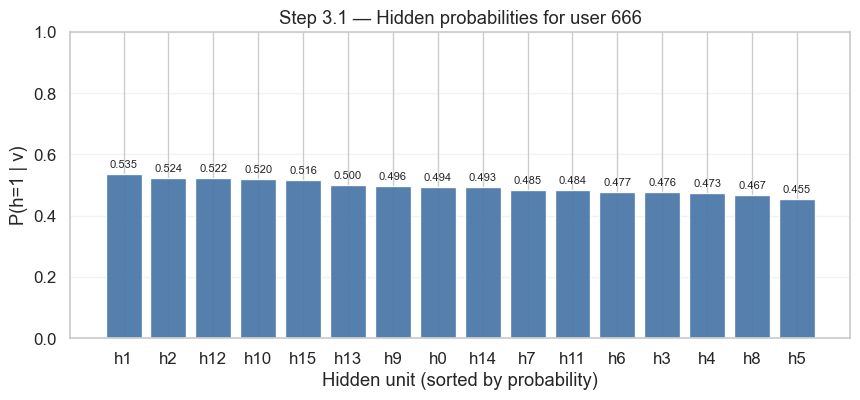

In [23]:
# Step 3.1 — Positive phase only: Eq.(2) on full V (user 666)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert 'V' in globals(), 'Run Step 1 first (build V).'
assert 'W_init' in globals() and 'b_h_init' in globals(), 'Run Step 2 first (W_init and b_h_init).';

W_used = W_init
b_h_used = b_h_init

# Eq. (2): a_j = b_j + sum_{i,k} v_i^k W_{ijk}
a_h = b_h_used + np.einsum('kn,knf->f', V, W_used)   # shape: (F,)

# Conditional Bernoulli probabilities for hidden units
h_prob = 1.0 / (1.0 + np.exp(-a_h))         # shape: (F,)

print('Positive phase (Eq.2) on user 666:')
print(f'  V shape      : {V.shape} (K, N)')
print(f'  W shape      : {W_used.shape} (K, N, F)')
print(f'  b_h shape    : {b_h_used.shape} (F,)')
print(f'  a_h shape    : {a_h.shape} (F,)')
print(f'  h_prob shape : {h_prob.shape} (F,)')
print(f'  N columns    : {V.shape[1]}')
print(f'  sum ones in V: {int(V.sum())}')

# Keep a compact parameter snapshot only (no weight histogram in Step 3)
print('  W snapshot:')
print(f'    min={W_used.min():.6f}, max={W_used.max():.6f}, mean={W_used.mean():.6f}, std={W_used.std():.6f}')
print('    W_used[0, :5, 0] =', np.round(W_used[0, :5, 0], 6))
print(f'    ||W||_F = {np.linalg.norm(W_used):.6f}')

print(f'  h_prob stats : min={h_prob.min():.6f}, max={h_prob.max():.6f}, mean={h_prob.mean():.6f}')

# Hidden-probability table (no hard thresholding)
hidden_table = pd.DataFrame({
    'hidden_id': np.arange(h_prob.size),
    'h_prob': np.round(h_prob, 6),
}).sort_values('h_prob', ascending=False).reset_index(drop=True)

print('  Hidden probability table (sorted by h_prob desc):')
print(hidden_table.to_string(index=False))

# One-figure summary: all hidden probabilities in one view
plot_df = hidden_table.copy().sort_values('h_prob', ascending=False).reset_index(drop=True)
labels = [f"h{int(i)}" for i in plot_df['hidden_id']]

fig, ax = plt.subplots(figsize=(8.8, 4.2))
bars = ax.bar(labels, plot_df['h_prob'].values, color='#4c78a8', edgecolor='white', alpha=0.95)
ax.set_ylim(0.0, 1.0)
ax.set_ylabel('P(h=1 | v)')
ax.set_xlabel('Hidden unit (sorted by probability)')
ax.set_title('Step 3.1 — Hidden probabilities for user 666')
ax.grid(axis='y', alpha=0.25)

for b, p in zip(bars, plot_df['h_prob'].values):
    ax.text(b.get_x() + b.get_width()/2, p + 0.015, f"{p:.3f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# keep for next phase
h_prob_666 = h_prob
a_h_666 = a_h

# snapshot weight tensor at Step3
W_step3 = W_used.copy()




### Step 3.2 — Bernoulli hidden sampling (stochastic)

From Step 3, we already have hidden probabilities:

$$
P(h_j=1\mid V)=\sigma\!\left(b_j+\sum_i\sum_k v_i^k W_{ij}^k\right)
$$

*(Source: `netflix.pdf` — Salakhutdinov et al., 2007, Eq. 2)*

Then we sample each hidden unit as a binary random variable:

$$
h_j \sim \mathrm{Bernoulli}\big(P(h_j=1\mid V)\big),\quad h_j\in\{0,1\}
$$

Equivalent PMF form (standard Bernoulli definition):

$$
P(h_j\mid V)=p_j^{h_j}(1-p_j)^{1-h_j},\quad p_j:=P(h_j=1\mid V),\; h_j\in\{0,1\}
$$

So explicitly:

$$
P(h_j=1\mid V)=p_j,\qquad P(h_j=0\mid V)=1-p_j
$$

*(Sampling step used in this notebook; Bernoulli parameter `p_j` comes from Eq. 2 above.)*

In code form for this notebook:

`h_sample_666[j] ~ Bernoulli(h_prob_666[j])`

So this step produces one binary activation snapshot (`0/1`) for the current run; with a different random seed, the sampled vector can change.

Bernoulli hidden sampling (one draw):
  seed used       : 42
  sample shape    : (16,)
  active count    : 9 / 16
  sampled vector (length 16): [1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1]
  sampled active indices: [0, 1, 3, 5, 6, 7, 10, 11, 15]
  sampled inactive indices: [2, 4, 8, 9, 12, 13, 14]

Hidden probability + sampled state table (sorted by h_prob desc):
 hidden_id   h_prob  h_sample
         1 0.535480         1
         2 0.523779         0
        12 0.522336         0
        10 0.520292         1
        15 0.516416         1
        13 0.500164         0
         9 0.496030         0
         0 0.494198         1
        14 0.492622         0
         7 0.484625         1
        11 0.484391         1
         6 0.476923         1
         3 0.476255         1
         4 0.472982         0
         8 0.467019         0
         5 0.454840         1


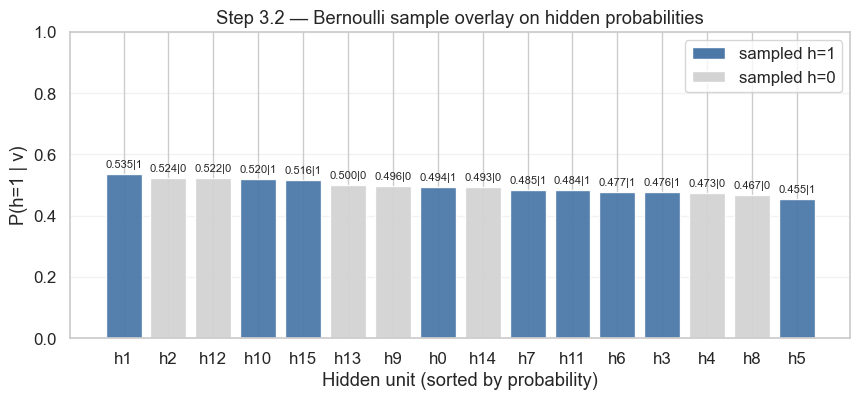

In [27]:
# Step 3.2 — Bernoulli sampling from h_prob_666 (one stochastic draw)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert 'h_prob_666' in globals(), 'Run Step 3 first (h_prob_666).'

seed_hidden_sample = 42
rng_hidden = np.random.default_rng(seed_hidden_sample)
h_sample_666 = rng_hidden.binomial(n=1, p=h_prob_666).astype(int)

hidden_sample_table = pd.DataFrame({
    'hidden_id': np.arange(h_prob_666.size),
    'h_prob': np.round(h_prob_666, 6),
    'h_sample': h_sample_666,
}).sort_values('h_prob', ascending=False).reset_index(drop=True)

print('Bernoulli hidden sampling (one draw):')
print(f'  seed used       : {seed_hidden_sample}')
print(f'  sample shape    : {h_sample_666.shape}')
print(f'  active count    : {int(h_sample_666.sum())} / {h_sample_666.size}')
print('  sampled active indices:', np.where(h_sample_666 == 1)[0].tolist())
print('  sampled inactive indices:', np.where(h_sample_666 == 0)[0].tolist())
print('\nHidden probability + sampled state table (sorted by h_prob desc):')
print(hidden_sample_table.to_string(index=False))

# one-figure summary
plot_df = hidden_sample_table.copy()
labels = [f"h{int(i)}" for i in plot_df['hidden_id']]
colors = np.where(plot_df['h_sample'].values == 1, '#4c78a8', '#d3d3d3')

fig, ax = plt.subplots(figsize=(8.8, 4.2))
bars = ax.bar(labels, plot_df['h_prob'].values, color=colors, edgecolor='white', alpha=0.95)
ax.set_ylim(0.0, 1.0)
ax.set_ylabel('P(h=1 | v)')
ax.set_xlabel('Hidden unit (sorted by probability)')
ax.set_title('Step 3.2 — Bernoulli sample overlay on hidden probabilities')
ax.grid(axis='y', alpha=0.25)

for b, p, s in zip(bars, plot_df['h_prob'].values, plot_df['h_sample'].values):
    ax.text(b.get_x() + b.get_width()/2, p + 0.015, f"{p:.3f}|{s}", ha='center', va='bottom', fontsize=8)

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='#4c78a8', label='sampled h=1'),
    Patch(facecolor='#d3d3d3', label='sampled h=0'),
]
ax.legend(handles=legend_handles, loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

# keep for optional stochastic path
h_sample_666_draw1 = h_sample_666.copy()
hidden_sample_table_666 = hidden_sample_table.copy()

### Step 3.3 — Multi-seed Bernoulli comparison (same user, same probabilities)

Keep `user 666` and `h_prob_666` fixed, and repeat Bernoulli sampling with multiple random seeds.
This isolates stochastic variability from seed choice only (not user/model changes).


Multi-seed Bernoulli summary (same h_prob_666):
 seed  active_count
   42             7
    7             5
  123            10
 2026            11
   99             5

Seed -> sampled vector (aligned with heatmap columns order):
  hidden order: ['h1', 'h2', 'h12', 'h10', 'h15', 'h13', 'h9', 'h0', 'h14', 'h7', 'h11', 'h6', 'h3', 'h4', 'h8', 'h5']
  seed=42: [0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0]
  seed=7: [0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1]
  seed=123: [0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1]
  seed=2026: [1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1]
  seed=99: [1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0]

Per-hidden sample frequency across seeds:
 hidden_id   h_prob  sample_on_freq_over_seeds
         1 0.535480                        0.4
         2 0.523779                        0.4
        12 0.522336                        0.6
        10 0.520292                        0.6
        15 0.516416                        0.8
        13 0.500164     

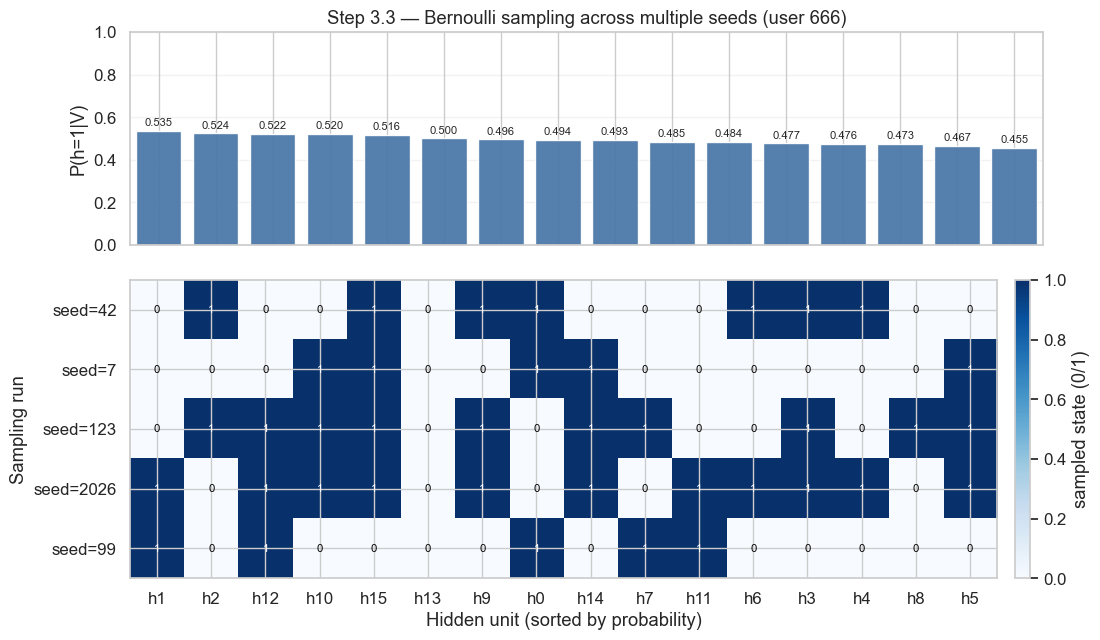

In [28]:
# Step 3.3 — Multi-seed Bernoulli sampling comparison (single figure)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert 'h_prob_666' in globals(), 'Run Step 3 first (h_prob_666).'

seeds_compare = [42, 7, 123, 2026, 99]

# Sort hidden units by probability (descending) for consistent display
order = np.argsort(-h_prob_666)
h_prob_sorted = h_prob_666[order]
labels_sorted = [f"h{int(i)}" for i in order]

samples = []
for s in seeds_compare:
    rng = np.random.default_rng(s)
    samples.append(rng.binomial(n=1, p=h_prob_sorted).astype(int))

samples_mat = np.vstack(samples)  # shape: (num_seeds, F)

# Summary table
summary_df = pd.DataFrame({
    'seed': seeds_compare,
    'active_count': samples_mat.sum(axis=1),
})
print('Multi-seed Bernoulli summary (same h_prob_666):')
print(summary_df.to_string(index=False))

print('\nSeed -> sampled vector (aligned with heatmap columns order):')
print('  hidden order:', labels_sorted)
for seed, vec in zip(seeds_compare, samples_mat):
    print(f'  seed={seed}: {vec.tolist()}')

freq_on = samples_mat.mean(axis=0)
freq_df = pd.DataFrame({
    'hidden_id': order,
    'h_prob': np.round(h_prob_sorted, 6),
    'sample_on_freq_over_seeds': np.round(freq_on, 3),
})
print('\nPer-hidden sample frequency across seeds:')
print(freq_df.to_string(index=False))

# Single figure: top = h_prob bars, bottom = sampled 0/1 heatmap by seed
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11.2, 6.6),
    gridspec_kw={'height_ratios': [1.0, 1.4]},
    sharex=True
)

x = np.arange(len(labels_sorted))
ax1.bar(x, h_prob_sorted, color='#4c78a8', edgecolor='white', alpha=0.95)
ax1.set_ylim(0, 1)
ax1.set_ylabel('P(h=1|V)')
ax1.set_title('Step 3.3 — Bernoulli sampling across multiple seeds (user 666)')
ax1.grid(axis='y', alpha=0.25)
for xi, p in zip(x, h_prob_sorted):
    ax1.text(xi, p + 0.015, f'{p:.3f}', ha='center', va='bottom', fontsize=8)

im = ax2.imshow(samples_mat, aspect='auto', cmap='Blues', vmin=0, vmax=1)
ax2.set_yticks(np.arange(len(seeds_compare)))
ax2.set_yticklabels([f'seed={s}' for s in seeds_compare])
ax2.set_xticks(x)
ax2.set_xticklabels(labels_sorted)
ax2.set_xlabel('Hidden unit (sorted by probability)')
ax2.set_ylabel('Sampling run')

# annotate 0/1 in cells
for r in range(samples_mat.shape[0]):
    for c in range(samples_mat.shape[1]):
        v = int(samples_mat[r, c])
        ax2.text(c, r, str(v), ha='center', va='center', color=('white' if v == 1 else 'black'), fontsize=8)

cbar = fig.colorbar(im, ax=ax2, fraction=0.03, pad=0.02)
cbar.set_label('sampled state (0/1)')

plt.tight_layout()
plt.show()

# keep for later
seeds_compare_666 = seeds_compare
h_samples_multi_seed_666 = samples_mat
h_order_multi_seed_666 = order

### Step 4 — Hidden to visible reconstruction (Eq. (1): $h \rightarrow V$)

Yes — this step is the **reconstruction** step.
Using hidden activations from Step 3 (`h_prob_666`), compute visible probabilities by Eq. (1):

$$
p(v_i^k=1\mid h)=\frac{\exp\left(b_i^k+\sum_j h_j W_{ijk}\right)}{\sum_{\ell=1}^{K}\exp\left(b_i^{\ell}+\sum_j h_j W_{ij\ell}\right)}
$$

Output is a full reconstruction probability matrix of shape `(K, N)` over all 68 visible columns.


Reconstruction (Eq.1) on full user block:
  h_used shape        : (16,) (F,)
  logits shape        : (10, 68) (K, N)
  P(v|h) shape        : (10, 68) (K, N)
  N columns processed : 68
  max |sum_k p_k - 1| : 2.220e-16
  W snapshot:
    min=-0.043891, max=0.040258, mean=-0.000120, std=0.010054
    W_used[0, :5, 0] = [ 0.003047  0.003688 -0.005122  0.006789  0.007112]
    ||W||_F = 1.048762


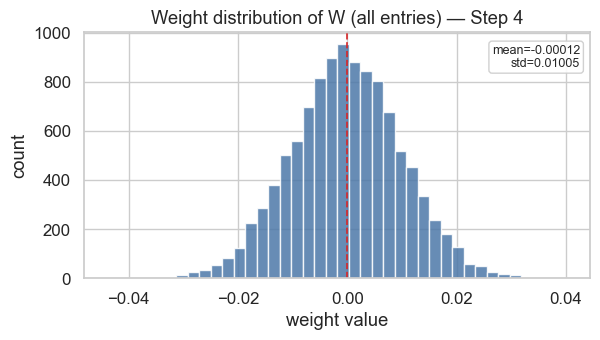

,col,movieId,timestamp,rating,level_index_k,half_star_level,true_rating_from_V,recon_level_index_k,recon_rating,prob_true_level_under_recon
0,0,1,1997-10-07 18:27:41,5.0,9,5.0,5.0,1,1.0,0.096940
1,1,6,1997-10-07 18:30:15,4.0,7,4.0,4.0,0,0.5,0.101127
2,2,17,1997-10-07 18:25:41,5.0,9,5.0,5.0,3,2.0,0.099282
3,3,25,1997-10-07 18:30:15,5.0,9,5.0,5.0,8,4.5,0.099359
4,4,32,1997-10-07 18:31:08,4.0,7,4.0,4.0,6,3.5,0.100203
...,...,...,...,...,...,...,...,...,...,...
63,63,1488,1997-10-07 18:27:41,1.0,1,1.0,1.0,4,2.5,0.099028
64,64,1569,1997-10-07 18:29:08,4.0,7,4.0,4.0,1,1.0,0.099359
65,65,1580,1997-10-07 18:25:02,4.0,7,4.0,4.0,1,1.0,0.098815
66,66,1584,1997-10-07 18:24:11,4.0,7,4.0,4.0,5,3.0,0.100091


In [15]:
# Step 4 — Reconstruction only: Eq.(1) from h to V

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert 'W_init' in globals() and 'b_v_init' in globals(), 'Run Step 2 first (W_init, b_v_init).';

W_used = W_init
b_v_used = b_v_init
assert 'h_prob_666' in globals(), 'Run Step 3 first to get h_prob_666.'
assert 'V' in globals(), 'Run Step 1 first (V).'
assert 'visible_table' in globals(), 'Run Step 1 first (visible_table).'

h_used = h_prob_666  # use positive-phase hidden probabilities from Step 3

# Eq. (1): logits_{k,i} = b_i^k + sum_j h_j W_{ijk}
logits = b_v_used + np.einsum('knf,f->kn', W_used, h_used)   # shape: (K, N)

# Softmax over rating levels k for each movie column i (axis=0)
logits_shift = logits - logits.max(axis=0, keepdims=True)
exp_logits = np.exp(logits_shift)
P_v_given_h = exp_logits / exp_logits.sum(axis=0, keepdims=True)  # shape: (K, N)

# Checks
col_sums = P_v_given_h.sum(axis=0)
max_col_sum_err = np.max(np.abs(col_sums - 1.0))

pred_k = np.argmax(P_v_given_h, axis=0)
pred_rating = np.array(RATING_LEVELS)[pred_k]
true_k = np.argmax(V, axis=0)
true_rating = np.array(RATING_LEVELS)[true_k]
prob_true_level = P_v_given_h[true_k, np.arange(V.shape[1])]

recon_68 = visible_table.copy()
recon_68['true_rating_from_V'] = true_rating
recon_68['recon_level_index_k'] = pred_k
recon_68['recon_rating'] = pred_rating
recon_68['prob_true_level_under_recon'] = prob_true_level

print('Reconstruction (Eq.1) on full user block:')
print(f'  h_used shape        : {h_used.shape} (F,)')
print(f'  logits shape        : {logits.shape} (K, N)')
print(f'  P(v|h) shape        : {P_v_given_h.shape} (K, N)')
print(f'  N columns processed : {V.shape[1]}')
print(f'  max |sum_k p_k - 1| : {max_col_sum_err:.3e}')

# Weight summary (friendly)
print('  W snapshot:')
print(f'    min={W_used.min():.6f}, max={W_used.max():.6f}, mean={W_used.mean():.6f}, std={W_used.std():.6f}')
print('    W_used[0, :5, 0] =', np.round(W_used[0, :5, 0], 6))
print(f'    ||W||_F = {np.linalg.norm(W_used):.6f}')

# Weight distribution plot
w_flat = W_used.ravel()
fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.hist(w_flat, bins=40, color='#4c78a8', alpha=0.85, edgecolor='white')
ax.axvline(0.0, color='#d62728', linestyle='--', linewidth=1.2)
ax.set_title('Weight distribution of W (all entries) — Step 4')
ax.set_xlabel('weight value')
ax.set_ylabel('count')
ax.text(0.98, 0.95, f'mean={w_flat.mean():.5f}\nstd={w_flat.std():.5f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#cccccc', alpha=0.9))
plt.tight_layout()
plt.show()

display(recon_68)

# keep for next phase
P_v_given_h_666 = P_v_given_h
recon_68_666 = recon_68

# snapshot weight tensor at Step4
W_step4 = W_used.copy()




### Step 5 Calculate the weight change


**Eq. (3): marginal over visible ratings**
$$
p(V)=\sum_{\mathbf{h}}\frac{\exp\big(-E(V,\mathbf{h})\big)}{\sum_{V',\mathbf{h}'}\exp\big(-E(V',\mathbf{h}')\big)}
$$

**Eq. (4): energy function**
$$
E(V,\mathbf{h})
=-\sum_{i=1}^{m}\sum_{j=1}^{F}\sum_{k=1}^{K}W_{ij}^{k}h_j v_i^{k}
+\sum_{i=1}^{m}\log Z_i
-\sum_{i=1}^{m}\sum_{k=1}^{K}v_i^{k}b_i^{k}
-\sum_{j=1}^{F}h_j b_j,
$$
with
$$
Z_i=\sum_{l=1}^{K}\exp\!\left(b_i^{l}+\sum_{j}h_jW_{ij}^{l}\right).
$$
(As in the paper, movies with missing ratings do not contribute to the energy.)

**Eq. (5): learning update**
$$
\Delta W_{ij}^{k}=\epsilon\,\frac{\partial \log p(V)}{\partial W_{ij}^{k}}
=\epsilon\left(\left\langle v_i^{k}h_j\right\rangle_{\text{data}}-\left\langle v_i^{k}h_j\right\rangle_{\text{model}}\right).
$$

So Step 5 implements **Eq. (5)** via CD-1 approximation (positive phase minus one-step model phase), then updates $W$, $b_v$, and $b_h$.



CD-1 single update completed:
  learning rate            : 0.05
  pos_W shape / neg_W shape: (10, 68, 16) / (10, 68, 16)
  [magnitude]
  ||ΔW||_F                 : 0.775314
  ||Δb_v||_F               : 0.391203
  ||Δb_h||_2               : 0.004530
  [signed delta stats]
  ΔW stats                 : min=-0.002685, max=0.024363, mean=-0.000019, std=0.007433
  ΔW sign ratio            : >0 10.00%, <0 90.00%, =0 0.00%
  Δb_v stats               : min=-0.005279, max=0.045210, mean=0.000000, std=0.015002
  Δb_h stats               : min=-0.002476, max=0.001607, mean=-0.000191, std=0.001116
  W stats after update     : min=-0.046301, max=0.062014, mean=-0.000139, std=0.012470
  W[0, :5, 0] after update = [ 0.00056   0.001156 -0.007636  0.004318  0.004601]


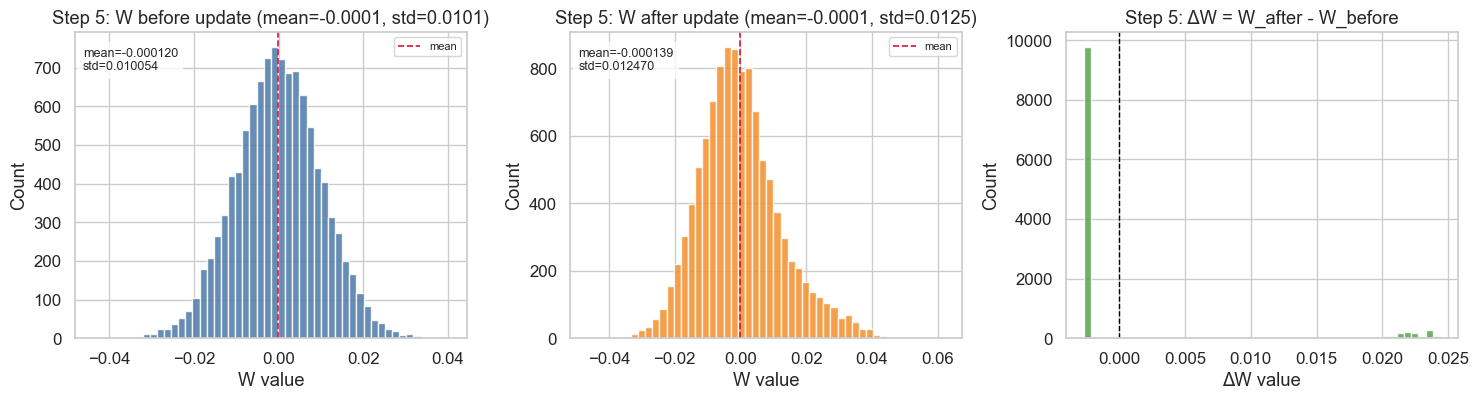

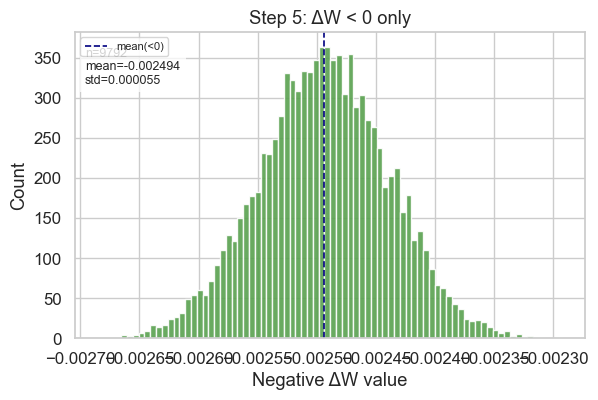

In [16]:
# Step 5 — One CD-1 update (data phase minus model phase)

import numpy as np
import matplotlib.pyplot as plt

assert 'V' in globals(), 'Run Step 1 first (V).'
assert 'h_prob_666' in globals(), 'Run Step 3 first (h_prob_666).'
assert 'P_v_given_h_666' in globals(), 'Run Step 4 first (P_v_given_h_666).'
assert 'W_init' in globals() and 'b_v_init' in globals() and 'b_h_init' in globals(), 'Run Step 2 first (W_init, b_v_init, b_h_init).'

lr = 0.05  # learning rate for this single update demo

# Keep old parameters for delta reporting
W_before = W_init.copy()
W_before_update = W_init.copy()
b_v_before = b_v_init.copy()
b_h_before = b_h_init.copy()

# Positive phase stats (data)
# <v h>_data approximated by V and h_prob_666
pos_W = np.einsum('kn,f->knf', V, h_prob_666)          # shape (K,N,F)

# Negative phase stats (model)
V_model = P_v_given_h_666                               # use reconstruction probabilities as 	ilde V
a_h_neg = b_h_before + np.einsum('kn,knf->f', V_model, W_before)
h_prob_neg = 1.0 / (1.0 + np.exp(-a_h_neg))            # 	ilde h probabilities
neg_W = np.einsum('kn,f->knf', V_model, h_prob_neg)    # <v h>_model

# Eq. (5) CD-1 updates (data term - one-step model term)
W_cd1 = W_before + lr * (pos_W - neg_W)
b_v_cd1 = b_v_before + lr * (V - V_model)
b_h_cd1 = b_h_before + lr * (h_prob_666 - h_prob_neg)

# Deltas / checks
dW = W_cd1 - W_before
dbv = b_v_cd1 - b_v_before
dbh = b_h_cd1 - b_h_before

print('CD-1 single update completed:')
print(f'  learning rate            : {lr}')
print(f'  pos_W shape / neg_W shape: {pos_W.shape} / {neg_W.shape}')

# Magnitude view (norms)
print('  [magnitude]')
print(f'  ||ΔW||_F                 : {np.linalg.norm(dW):.6f}')
print(f'  ||Δb_v||_F               : {np.linalg.norm(dbv):.6f}')
print(f'  ||Δb_h||_2               : {np.linalg.norm(dbh):.6f}')

# Signed view (direction + distribution)
dW_pos_ratio = (dW > 0).mean()
dW_neg_ratio = (dW < 0).mean()
dW_zero_ratio = (dW == 0).mean()

print('  [signed delta stats]')
print(f'  ΔW stats                 : min={dW.min():.6f}, max={dW.max():.6f}, mean={dW.mean():.6f}, std={dW.std():.6f}')
print(f'  ΔW sign ratio            : >0 {dW_pos_ratio:.2%}, <0 {dW_neg_ratio:.2%}, =0 {dW_zero_ratio:.2%}')
print(f'  Δb_v stats               : min={dbv.min():.6f}, max={dbv.max():.6f}, mean={dbv.mean():.6f}, std={dbv.std():.6f}')
print(f'  Δb_h stats               : min={dbh.min():.6f}, max={dbh.max():.6f}, mean={dbh.mean():.6f}, std={dbh.std():.6f}')

print(f'  W stats after update     : min={W_cd1.min():.6f}, max={W_cd1.max():.6f}, mean={W_cd1.mean():.6f}, std={W_cd1.std():.6f}')
print('  W[0, :5, 0] after update =', np.round(W_cd1[0, :5, 0], 6))

# Visualize W distributions: before vs after, then delta
w_before_flat = W_before_update.ravel()
w_after_flat = W_cd1.ravel()
dw_flat = dW.ravel()

w_before_mean, w_before_std = w_before_flat.mean(), w_before_flat.std()
w_after_mean, w_after_std = w_after_flat.mean(), w_after_flat.std()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].hist(w_before_flat, bins=50, color='#4e79a7', alpha=0.85)
axes[0].axvline(w_before_mean, color='crimson', linestyle='--', linewidth=1.2, label='mean')
axes[0].set_title(f'Step 5: W before update (mean={w_before_mean:.4f}, std={w_before_std:.4f})')
axes[0].set_xlabel('W value')
axes[0].set_ylabel('Count')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].text(0.02, 0.95, f'mean={w_before_mean:.6f}\nstd={w_before_std:.6f}', transform=axes[0].transAxes, va='top', fontsize=9, bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))

axes[1].hist(w_after_flat, bins=50, color='#f28e2b', alpha=0.85)
axes[1].axvline(w_after_mean, color='crimson', linestyle='--', linewidth=1.2, label='mean')
axes[1].set_title(f'Step 5: W after update (mean={w_after_mean:.4f}, std={w_after_std:.4f})')
axes[1].set_xlabel('W value')
axes[1].set_ylabel('Count')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].text(0.02, 0.95, f'mean={w_after_mean:.6f}\nstd={w_after_std:.6f}', transform=axes[1].transAxes, va='top', fontsize=9, bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))

axes[2].hist(dw_flat, bins=50, color='#59a14f', alpha=0.85)
axes[2].axvline(0.0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Step 5: ΔW = W_after - W_before')
axes[2].set_xlabel('ΔW value')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()


# Extra ΔW view: negative-only distribution
neg_dw = dw_flat[dw_flat < 0]

fig3, ax3 = plt.subplots(1, 1, figsize=(6.2, 4.2))
if neg_dw.size > 0:
    ax3.hist(neg_dw, bins=80, color='#59a14f', alpha=0.9)
    ax3.axvline(neg_dw.mean(), color='navy', linestyle='--', linewidth=1.2, label='mean(<0)')
    ax3.set_title('Step 5: ΔW < 0 only')
    ax3.set_xlabel('Negative ΔW value')
    ax3.set_ylabel('Count')
    ax3.legend(loc='upper left', fontsize=8)
    ax3.text(0.02, 0.95,
             f'n={neg_dw.size}\nmean={neg_dw.mean():.6f}\nstd={neg_dw.std():.6f}',
             transform=ax3.transAxes, va='top', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))
else:
    ax3.text(0.5, 0.5, 'No negative ΔW values', ha='center', va='center', fontsize=11)
    ax3.set_title('Step 5: ΔW < 0 only')
    ax3.set_xlabel('Negative ΔW value')
    ax3.set_ylabel('Count')

plt.tight_layout()
plt.show()

plt.show()

# Save for later comparison
h_prob_neg_666 = h_prob_neg
V_model_666 = V_model

# snapshots for explicit before/after comparison
W_after_update = W_cd1.copy()

# Optional: promote updated params as current params
W = W_cd1
b_v = b_v_cd1
b_h = b_h_cd1






